## Advanced Modeling v3: Enriched Features + Feature Category System

Improvements over v2:
- **Richer dataset** — uses `news_prices_full_processed_with_target_v3.parquet`, which adds OHLCV, lag prices/volumes/returns, S&P500 lags, alpha, momentum, volatility and calendar features
- **Feature category system** — every feature group is named; set `EXCLUDE_CATEGORIES` to ablate any group with one line
- **No leakage audit** — `LEAKY_COLS` explicitly removes target-derived and future columns before anything is built
- **Baseline first** — a model with *zero* text is run before any vectoriser, so the text uplift is clearly visible
- **Four text methods** — `tf-idf-svd` · `word2vec` · `bert` · `finbert`, each concatenated with the full non-text feature matrix
- **Per-group importance** — after training, feature importance is aggregated back to category level

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())   # makes 'vectorizer' importable from modeling/

import json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from vectorizer import preprocess_tokenize, vectorize

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110})

## 1. Load Data

In [2]:
df_raw = pd.read_parquet('../data/data_sample/news_prices_full_processed_with_target_v2.parquet')
print(f'Raw dataset: {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}):')
print(list(df_raw.columns))

Raw dataset: (84658, 156)
Columns (156):
['date', 'prev_date', 'future_date', 'title', 'description', 'maintext', 'ticker', 'prev_day_price', 'curr_day_price', 'next_day_price', 'named_entities', 'mentioned_companies', 'related_companies', 'sentiment_negative', 'sentiment_neutral', 'sentiment_positive', 'emotion_anger', 'emotion_fear', 'emotion_joy', 'emotion_sadness', 'emotion_disgust', 'emotion_surprise', 'emotion_neutral', 'date_day_of_week', 'prev_day_of_week', 'future_day_of_week', 'language', 'curr_prev_per_change', 'next_curr_per_change', 'curr_prev_pos_change', 'next_curr_pos_change', 'title_word_count', 'description_word_count', 'maintext_word_count', 'title + description + maintext', 'title + description', 'S&P500', 'sector', 'industry', 'marketcap', 'ebitda', 'revenue_growth', 'full_time_employees', 'long_business_summary', 'weight', 'curr_open', 'curr_high', 'curr_low', 'curr_volume', 'curr_day_range', 'curr_day_gap', 'curr_upper_wick', 'curr_lower_wick', 'close_lag2', 'vol

## 2. Outlier Removal & Sampling

In [3]:
TARGET   = 'next_curr_per_change'
TEXT_COL = 'title + description + maintext'

print('Target distribution (raw):')
print(df_raw[TARGET].describe(percentiles=[.01, .05, .1, .9, .95, .99]))

q01 = df_raw[TARGET].quantile(0.02)
q99 = df_raw[TARGET].quantile(0.99)
print(f'\nClipping to [{q01:.4f}, {q99:.4f}]')

df = (
    df_raw
    .dropna(subset=[TARGET, 'maintext'])
    .query(f'{q01} <= {TARGET} <= {q99}')
    .reset_index(drop=True)
)
print(f'After outlier removal: {df.shape}')

Target distribution (raw):
count    84658.000000
mean         0.000348
std          0.027513
min         -0.951267
1%          -0.060640
5%          -0.031918
10%         -0.022697
50%          0.000661
90%          0.022022
95%          0.033405
99%          0.066453
max          0.197623
Name: next_curr_per_change, dtype: float64

Clipping to [-0.0468, 0.0665]
After outlier removal: (82133, 156)


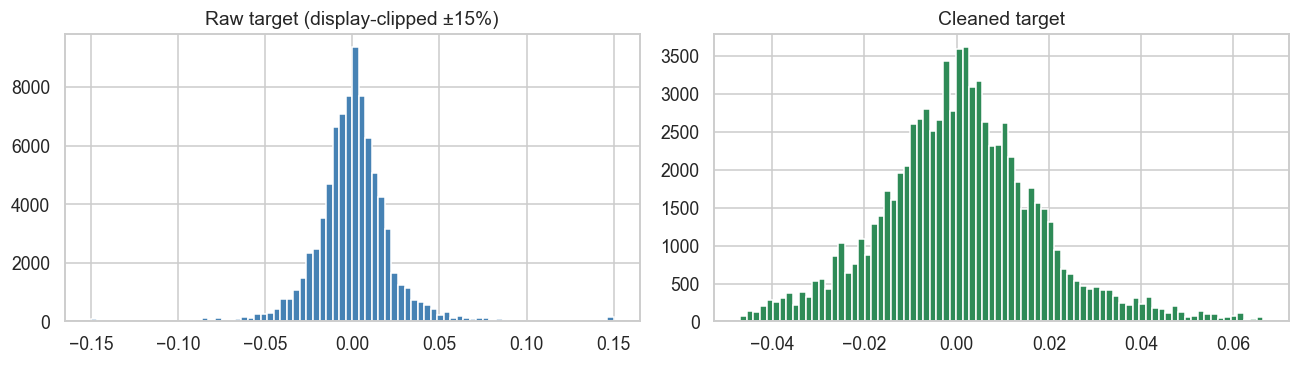

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
df_raw[TARGET].clip(-0.15, 0.15).hist(bins=80, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Raw target (display-clipped ±15%)')
df[TARGET].hist(bins=80, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Cleaned target')
plt.tight_layout()
plt.show()

In [5]:
# ── Sampling — set to 1.0 for full data (slower) ─────────────────────────────
# SAMPLE_FRAC = 0.1
SAMPLE_FRAC = 1

if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    print(f'Sampled to {SAMPLE_FRAC*100:.0f}%: {df.shape}')
else:
    print(f'Using full dataset: {df.shape}')

Using full dataset: (82133, 156)


## 3. Leakage Prevention

The following columns are **removed before any feature is built**:
- `next_day_price` — this is the numerator of the target; using it is pure leakage  
- `next_curr_pos_change` — binary version of the target  
- `future_date` — a future date that shouldn't be a model input

All lag features in the dataset look *backward* from `date`, so they are safe.  
Current-day OHLCV features assume an **end-of-day prediction window** (article read after market close).

In [6]:
LEAKY_COLS = ['next_day_price', 'next_curr_pos_change', 'future_date']
dropped = [c for c in LEAKY_COLS if c in df.columns]
df = df.drop(columns=dropped)
print(f'Dropped leaky columns: {dropped}')
print(f'Shape after leakage removal: {df.shape}')

Dropped leaky columns: ['next_day_price', 'next_curr_pos_change', 'future_date']
Shape after leakage removal: (82133, 153)


## 4. Feature Categories

Every feature group is registered in `FEATURE_CATEGORIES`.  
Add the group key to `EXCLUDE_CATEGORIES` to drop the whole group from the model — useful for ablation studies.

| Key | Contents |
|---|---|
| `sentiment` | Pre-computed negative / neutral / positive scores |
| `emotion` | anger, fear, joy, sadness, disgust, surprise, neutral |
| `text_stats` | Word counts for title, description, maintext |
| `price_momentum` | Current-day return (`curr_prev_per_change`) and direction |
| `curr_ohlcv` | Current-day volume, intraday range, gap, wicks |
| `lag_prices` | Raw close prices at lag 2–28 calendar days |
| `lag_volumes` | Volume at lag 2–28 |
| `sp500_current` | S&P 500 level on the article date |
| `lag_sp500` | S&P 500 at lag 2–28 |
| `lag_returns` | Stock return from lagN to current |
| `lag_directions` | Direction (up/down) of those returns |
| `sp500_returns` | S&P 500 return from lagN to current |
| `sp500_directions` | Direction of S&P 500 returns |
| `volume_changes` | Volume change vs each lag + rolling averages |
| `alpha` | Stock return minus S&P 500 return per lag |
| `momentum` | Differences between returns across horizons |
| `price_range` | Price position within recent high/low range |
| `hist_volatility` | Std of log-returns across lag chain |
| `calendar` | Month, quarter, week, month/quarter-end flags |
| `company_meta` | Marketcap, EBITDA, revenue growth, employees, weight |
| `company_counts` | Number of mentioned / related companies in article |
| `dow` | Day-of-week one-hot (categorical) |
| `ticker` | Ticker one-hot (top-50 + OTHER, categorical) |
| `sector` | Sector one-hot (categorical) |

In [7]:
# ── Compute derived counts from JSON columns ───────────────────────────────────
def count_json_list(s):
    try:
        lst = json.loads(s)
        return len(lst) if isinstance(lst, list) else 0
    except Exception:
        return 0

df['n_mentioned'] = df['mentioned_companies'].apply(count_json_list)
df['n_related']   = df['related_companies'].apply(count_json_list)
print(f"n_mentioned  — mean: {df['n_mentioned'].mean():.2f}, max: {df['n_mentioned'].max()}")
print(f"n_related    — mean: {df['n_related'].mean():.2f}, max: {df['n_related'].max()}")

n_mentioned  — mean: 1.88, max: 12
n_related    — mean: 311.23, max: 3722


In [8]:
LAGS = [2, 3, 4, 5, 7, 14, 21, 28]

# ── Numeric feature groups ─────────────────────────────────────────────────────
FEATURE_CATEGORIES = {
    # NLP pre-computed
    'sentiment':       ['sentiment_negative', 'sentiment_neutral', 'sentiment_positive'],
    'emotion':         ['emotion_anger', 'emotion_fear', 'emotion_joy', 'emotion_sadness',
                        'emotion_disgust', 'emotion_surprise', 'emotion_neutral'],
    'text_stats':      ['title_word_count', 'description_word_count', 'maintext_word_count'],
    # Current-day price signals
    'price_momentum':  ['curr_prev_per_change', 'curr_prev_pos_change'],
    'curr_ohlcv':      ['curr_volume', 'curr_day_range', 'curr_day_gap',
                        'curr_upper_wick', 'curr_lower_wick'],
    # Lagged price history
    'lag_prices':      [f'close_lag{l}' for l in LAGS],
    'lag_volumes':     [f'volume_lag{l}' for l in LAGS],
    # S&P 500
    'sp500_current':   ['S&P500'],
    'lag_sp500':       [f'sp500_lag{l}' for l in LAGS],
    # Return / direction signals
    'lag_returns':     [f'ret_lag{l}' for l in LAGS],
    'lag_directions':  [f'dir_lag{l}' for l in LAGS],
    'sp500_returns':   [f'sp500_ret_lag{l}' for l in LAGS],
    'sp500_directions': [f'sp500_dir_lag{l}' for l in LAGS],
    # Volume
    'volume_changes':  ([f'vol_change_lag{l}' for l in LAGS] +
                        ['avg_vol_7d', 'avg_vol_28d', 'rel_vol_7d', 'rel_vol_28d']),
    # Alpha & momentum
    'alpha':           [f'alpha_lag{l}' for l in LAGS],
    'momentum':        ['momentum_2_7', 'momentum_7_28', 'momentum_2_28',
                        'momentum_2_5', 'momentum_5_14',
                        'sp500_momentum_2_7', 'sp500_momentum_7_28', 'sp500_momentum_2_28'],
    # Range & volatility
    'price_range':     ['recent_high_7d', 'recent_low_7d', 'recent_high_28d', 'recent_low_28d',
                        'price_vs_7d_low', 'price_vs_7d_high',
                        'price_vs_28d_low', 'price_vs_28d_high',
                        'price_position_7d', 'price_position_28d'],
    'hist_volatility': ['hist_volatility_approx', 'hist_volatility_7d'],
    # Calendar
    'calendar':        ['month', 'quarter', 'week_of_year',
                        'is_month_start', 'is_month_end', 'is_quarter_end', 'day_of_week_num'],
    # Company metadata
    'company_meta':    ['marketcap', 'ebitda', 'revenue_growth', 'full_time_employees', 'weight'],
    'company_counts':  ['n_mentioned', 'n_related'],
}

# ── Categorical groups (one-hot encoded) ──────────────────────────────────────
CATEGORICAL_FEATURES = {
    'dow':    'date_day_of_week',   # 5 values
    'ticker': 'ticker',             # top-50 + OTHER
    'sector': 'sector',             # from sp500_companies
}

total = sum(len(v) for v in FEATURE_CATEGORIES.values())
print(f'Total numeric feature slots defined: {total}')
print(f'Categorical groups: {list(CATEGORICAL_FEATURES.keys())}')

Total numeric feature slots defined: 131
Categorical groups: ['dow', 'ticker', 'sector']


In [9]:
# ── CONFIGURE EXCLUSIONS HERE ─────────────────────────────────────────────────
# Add category keys from FEATURE_CATEGORIES or CATEGORICAL_FEATURES to ablate them.
# Example: EXCLUDE_CATEGORIES = ['lag_prices', 'lag_volumes', 'lag_sp500']
EXCLUDE_CATEGORIES = []
# ─────────────────────────────────────────────────────────────────────────────

In [10]:
def build_feature_matrix(df, exclude_categories=None):
    """Build the non-text feature matrix.
    
    Parameters
    ----------
    df : DataFrame — the working dataset (after sampling)
    exclude_categories : list of str — category keys to drop entirely

    Returns
    -------
    X : np.ndarray  shape (n_samples, n_features)
    feature_names : list[str]
    col_to_cat : dict  feature_name -> category_key  (for importance grouping)
    """
    if exclude_categories is None:
        exclude_categories = []

    print(f"\n{'='*58}")
    print(f"  Building feature matrix  "
          f"(excluded: {exclude_categories if exclude_categories else 'none'})")
    print(f"{'='*58}")

    col_to_cat = {}  # tracks which category each final column belongs to

    # ── numeric features ──────────────────────────────────────────────────────
    active_cols = []
    for cat_key, cols in FEATURE_CATEGORIES.items():
        if cat_key in exclude_categories:
            print(f"  SKIP   {cat_key:<22} ({len(cols)} features)")
            continue
        available = [c for c in cols if c in df.columns]
        missing   = [c for c in cols if c not in df.columns]
        status    = 'OK  ' if not missing else 'WARN'
        note      = (f"  ({len(missing)} missing: {missing[:2]}{'...' if len(missing)>2 else ''})" if missing else '')
        print(f"  {status}   {cat_key:<22} {len(available):>3} features{note}")
        for c in available:
            col_to_cat[c] = cat_key
        active_cols.extend(available)

    X_num = df[active_cols].fillna(0).astype(np.float32).values
    feat_names = list(active_cols)

    # ── categorical features (one-hot) ────────────────────────────────────────
    cat_parts = []
    for cat_key, col in CATEGORICAL_FEATURES.items():
        if cat_key in exclude_categories:
            print(f"  SKIP   {cat_key:<22} (categorical)")
            continue
        if col not in df.columns:
            print(f"  MISS   {cat_key:<22} ({col} not in df)")
            continue

        if cat_key == 'ticker':
            top_vals = df[col].value_counts().nlargest(50).index
            series = df[col].where(df[col].isin(top_vals), 'OTHER')
        else:
            series = df[col].fillna('Unknown')

        dummies = pd.get_dummies(series, prefix=cat_key).astype(np.float32)
        print(f"  OK     {cat_key:<22} {dummies.shape[1]:>3} one-hot columns")
        for c in dummies.columns:
            col_to_cat[str(c)] = cat_key
        feat_names.extend(list(dummies.columns.astype(str)))
        cat_parts.append(dummies.values)

    X = np.hstack([X_num] + cat_parts) if cat_parts else X_num
    print(f"\n  → Feature matrix shape: {X.shape}")
    return X, feat_names, col_to_cat


X_features, feature_names, col_to_cat = build_feature_matrix(df, EXCLUDE_CATEGORIES)
print(f'\nFeature names sample: {feature_names[:5]} ... {feature_names[-3:]}')


  Building feature matrix  (excluded: none)
  OK     sentiment                3 features
  OK     emotion                  7 features
  OK     text_stats               3 features
  OK     price_momentum           2 features
  OK     curr_ohlcv               5 features
  OK     lag_prices               8 features
  OK     lag_volumes              8 features
  OK     sp500_current            1 features
  OK     lag_sp500                8 features
  OK     lag_returns              8 features
  OK     lag_directions           8 features
  OK     sp500_returns            8 features
  OK     sp500_directions         8 features
  OK     volume_changes          12 features
  OK     alpha                    8 features
  OK     momentum                 8 features
  OK     price_range             10 features
  OK     hist_volatility          2 features
  OK     calendar                 7 features
  OK     company_meta             5 features
  OK     company_counts           2 features
  OK     d

## 5. Text Preprocessing

In [11]:
texts = df[TEXT_COL].fillna('').astype(str).tolist()
preprocessed, tokenized = preprocess_tokenize(texts)

Preprocessing and tokenizing corpus
Preprocessed 82133 documents


## 6. Shared Split + Helpers

All models use **identical** train / val / test indices — results are directly comparable.  
Split: **60 / 20 / 20** (random, `random_state=42`).

In [12]:
y = df[TARGET].values.astype(np.float32)

idx_all = np.arange(len(df))
idx_trainval, idx_test  = train_test_split(idx_all,      test_size=0.1, random_state=42)
idx_train,    idx_val   = train_test_split(idx_trainval, test_size=0.15, random_state=42)

y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]
print(f'Train: {len(idx_train):,}  |  Val: {len(idx_val):,}  |  Test: {len(idx_test):,}')

results        = []          # one dict per model
trained_models = {}          # method_name -> (model, feature_names, col_to_cat)


def train_catboost(X_tr, y_tr, X_vl, y_vl, verbose=200):
    model = CatBoostRegressor(
        iterations=3000,
        early_stopping_rounds=100,
    )
    model.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))
    return model


def evaluate(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    rec = {
        'Method':    name,
        'RMSE':      float(np.sqrt(mean_squared_error(y_te, y_pred))),
        'MAE':       float(mean_absolute_error(y_te, y_pred)),
        'Median AE': float(np.median(np.abs(y_te - y_pred))),
        'R²':        float(r2_score(y_te, y_pred)),
    }
    print(f"\n{'='*42}")
    print(f'  {name}')
    print(f"{'='*42}")
    for k, v in rec.items():
        if k != 'Method':
            print(f'  {k:<12}: {v:.6f}')
    return rec


def slice_dense(X):
    return X[idx_train], X[idx_val], X[idx_test]

Train: 62,831  |  Val: 11,088  |  Test: 8,214


---
## Baseline — Numerical + Categorical Features, No Text

This is the performance ceiling attributable purely to price history, sentiment scores, company metadata, and calendar features — **no text whatsoever**. Every text method below must beat this baseline to justify the extra cost.

In [13]:
X_tr, X_vl, X_te = slice_dense(X_features)
model_base = train_catboost(X_tr, y_train, X_vl, y_val)
res_base   = evaluate(model_base, X_te, y_test, 'Baseline (no text)')
results.append(res_base)
trained_models['Baseline (no text)'] = (model_base, feature_names, col_to_cat)

Learning rate set to 0.049907
0:	learn: 0.0172970	test: 0.0173544	best: 0.0173544 (0)	total: 81.3ms	remaining: 4m 3s
1:	learn: 0.0172394	test: 0.0173061	best: 0.0173061 (1)	total: 91.4ms	remaining: 2m 16s
2:	learn: 0.0171679	test: 0.0172425	best: 0.0172425 (2)	total: 99.6ms	remaining: 1m 39s
3:	learn: 0.0171142	test: 0.0171960	best: 0.0171960 (3)	total: 106ms	remaining: 1m 19s
4:	learn: 0.0170640	test: 0.0171485	best: 0.0171485 (4)	total: 113ms	remaining: 1m 7s
5:	learn: 0.0170142	test: 0.0171025	best: 0.0171025 (5)	total: 120ms	remaining: 1m
6:	learn: 0.0169642	test: 0.0170505	best: 0.0170505 (6)	total: 127ms	remaining: 54.2s
7:	learn: 0.0169335	test: 0.0170221	best: 0.0170221 (7)	total: 133ms	remaining: 49.9s
8:	learn: 0.0168889	test: 0.0169826	best: 0.0169826 (8)	total: 139ms	remaining: 46.3s
9:	learn: 0.0168469	test: 0.0169440	best: 0.0169440 (9)	total: 145ms	remaining: 43.5s
10:	learn: 0.0167822	test: 0.0168886	best: 0.0168886 (10)	total: 152ms	remaining: 41.4s
11:	learn: 0.016741

---
## Method 1 — TF-IDF SVD (300d) + Features

TF-IDF (10k bigrams) → TruncatedSVD to 300 dense dimensions, concatenated with `X_features`.

In [14]:
X_tfidf, tfidf_pipe = vectorize('tf-idf-svd', preprocessed, tokenized)
print(f'TF-IDF SVD embedding shape: {X_tfidf.shape}')

X_tfidf_full = np.hstack([X_tfidf, X_features])
print(f'TF-IDF SVD + features shape: {X_tfidf_full.shape}')

X_tr, X_vl, X_te = slice_dense(X_tfidf_full)
model_tfidf = train_catboost(X_tr, y_train, X_vl, y_val)
res_tfidf   = evaluate(model_tfidf, X_te, y_test, 'TF-IDF SVD + features')
results.append(res_tfidf)

tfidf_names = [f'tfidf_{i}' for i in range(X_tfidf.shape[1])] + feature_names
tfidf_c2c   = {f'tfidf_{i}': 'text_embedding' for i in range(X_tfidf.shape[1])}
tfidf_c2c.update(col_to_cat)
trained_models['TF-IDF SVD + features'] = (model_tfidf, tfidf_names, tfidf_c2c)

Vectorizing using method: tf-idf-svd
Creating TF-IDF matrix with SVD
TF-IDF SVD embedding shape: (82133, 300)
TF-IDF SVD + features shape: (82133, 487)
Learning rate set to 0.049907
0:	learn: 0.0172660	test: 0.0173280	best: 0.0173280 (0)	total: 59.5ms	remaining: 2m 58s
1:	learn: 0.0172007	test: 0.0172710	best: 0.0172710 (1)	total: 80.4ms	remaining: 2m
2:	learn: 0.0171625	test: 0.0172380	best: 0.0172380 (2)	total: 113ms	remaining: 1m 53s
3:	learn: 0.0171150	test: 0.0171947	best: 0.0171947 (3)	total: 133ms	remaining: 1m 39s
4:	learn: 0.0170697	test: 0.0171558	best: 0.0171558 (4)	total: 154ms	remaining: 1m 32s
5:	learn: 0.0170179	test: 0.0171117	best: 0.0171117 (5)	total: 172ms	remaining: 1m 26s
6:	learn: 0.0169780	test: 0.0170728	best: 0.0170728 (6)	total: 194ms	remaining: 1m 22s
7:	learn: 0.0169207	test: 0.0170188	best: 0.0170188 (7)	total: 224ms	remaining: 1m 23s
8:	learn: 0.0168723	test: 0.0169728	best: 0.0169728 (8)	total: 244ms	remaining: 1m 20s
9:	learn: 0.0168349	test: 0.0169375	b

---
## Method 2 — Word2Vec (300d) + Features

Skip-gram Word2Vec trained on the corpus. Document vector = mean of in-vocabulary word vectors.

In [15]:
X_w2v, w2v_model = vectorize('word2vec', preprocessed, tokenized)
print(f'Word2Vec embedding shape: {X_w2v.shape}')

X_w2v_full = np.hstack([X_w2v, X_features])
print(f'Word2Vec + features shape: {X_w2v_full.shape}')

X_tr, X_vl, X_te = slice_dense(X_w2v_full)
model_w2v = train_catboost(X_tr, y_train, X_vl, y_val)
res_w2v   = evaluate(model_w2v, X_te, y_test, 'Word2Vec + features')
results.append(res_w2v)

w2v_names = [f'w2v_{i}' for i in range(X_w2v.shape[1])] + feature_names
w2v_c2c   = {f'w2v_{i}': 'text_embedding' for i in range(X_w2v.shape[1])}
w2v_c2c.update(col_to_cat)
trained_models['Word2Vec + features'] = (model_w2v, w2v_names, w2v_c2c)

Vectorizing using method: word2vec
Training Word2Vec model
Word2Vec embedding shape: (82133, 300)
Word2Vec + features shape: (82133, 487)
Learning rate set to 0.049907
0:	learn: 0.0172660	test: 0.0173280	best: 0.0173280 (0)	total: 166ms	remaining: 8m 17s
1:	learn: 0.0172007	test: 0.0172710	best: 0.0172710 (1)	total: 200ms	remaining: 5m
2:	learn: 0.0171625	test: 0.0172380	best: 0.0172380 (2)	total: 217ms	remaining: 3m 36s
3:	learn: 0.0171150	test: 0.0171947	best: 0.0171947 (3)	total: 234ms	remaining: 2m 55s
4:	learn: 0.0170697	test: 0.0171558	best: 0.0171558 (4)	total: 253ms	remaining: 2m 31s
5:	learn: 0.0170179	test: 0.0171117	best: 0.0171117 (5)	total: 272ms	remaining: 2m 15s
6:	learn: 0.0169780	test: 0.0170728	best: 0.0170728 (6)	total: 289ms	remaining: 2m 3s
7:	learn: 0.0169207	test: 0.0170188	best: 0.0170188 (7)	total: 309ms	remaining: 1m 55s
8:	learn: 0.0168670	test: 0.0169684	best: 0.0169684 (8)	total: 329ms	remaining: 1m 49s
9:	learn: 0.0168349	test: 0.0169369	best: 0.0169369 (9

---
## Method 3 — BERT / Sentence-BERT (384d) + Features

Uses `all-MiniLM-L6-v2` via `sentence-transformers`. Auto-detects device (MPS → CUDA → CPU).

In [16]:
X_bert, bert_model = vectorize('bert', preprocessed, tokenized)
print(f'BERT embedding shape: {X_bert.shape}')

X_bert_full = np.hstack([X_bert, X_features])
print(f'BERT + features shape: {X_bert_full.shape}')

X_tr, X_vl, X_te = slice_dense(X_bert_full)
model_bert = train_catboost(X_tr, y_train, X_vl, y_val)
res_bert   = evaluate(model_bert, X_te, y_test, 'BERT + features')
results.append(res_bert)

bert_names = [f'bert_{i}' for i in range(X_bert.shape[1])] + feature_names
bert_c2c   = {f'bert_{i}': 'text_embedding' for i in range(X_bert.shape[1])}
bert_c2c.update(col_to_cat)
trained_models['BERT + features'] = (model_bert, bert_names, bert_c2c)

Vectorizing using method: bert
Love. Death. TRANSFORMERS
Using device: mps
Creating Sentence-BERT embeddings


Batches:   0%|          | 0/1712 [00:00<?, ?it/s]

BERT embedding shape: (82133, 384)
BERT + features shape: (82133, 571)
Learning rate set to 0.049907
0:	learn: 0.0172837	test: 0.0173430	best: 0.0173430 (0)	total: 137ms	remaining: 6m 49s
1:	learn: 0.0172215	test: 0.0172876	best: 0.0172876 (1)	total: 159ms	remaining: 3m 58s
2:	learn: 0.0171636	test: 0.0172394	best: 0.0172394 (2)	total: 179ms	remaining: 2m 59s
3:	learn: 0.0171124	test: 0.0171963	best: 0.0171963 (3)	total: 199ms	remaining: 2m 28s
4:	learn: 0.0170798	test: 0.0171669	best: 0.0171669 (4)	total: 219ms	remaining: 2m 11s
5:	learn: 0.0170396	test: 0.0171309	best: 0.0171309 (5)	total: 242ms	remaining: 2m
6:	learn: 0.0169983	test: 0.0170954	best: 0.0170954 (6)	total: 261ms	remaining: 1m 51s
7:	learn: 0.0169535	test: 0.0170557	best: 0.0170557 (7)	total: 284ms	remaining: 1m 46s
8:	learn: 0.0168954	test: 0.0170040	best: 0.0170040 (8)	total: 308ms	remaining: 1m 42s
9:	learn: 0.0168434	test: 0.0169548	best: 0.0169548 (9)	total: 329ms	remaining: 1m 38s
10:	learn: 0.0168011	test: 0.0169

---
## Method 4 — FinBERT (768d) + Features

Uses `yiyanghkust/finbert-pretrain` — BERT pre-trained on financial text. Embedding = CLS token.

In [17]:
X_finbert, finbert_model = vectorize('finbert', preprocessed, tokenized)
print(f'FinBERT embedding shape: {X_finbert.shape}')

X_finbert_full = np.hstack([X_finbert, X_features])
print(f'FinBERT + features shape: {X_finbert_full.shape}')

X_tr, X_vl, X_te = slice_dense(X_finbert_full)
model_finbert = train_catboost(X_tr, y_train, X_vl, y_val)
res_finbert   = evaluate(model_finbert, X_te, y_test, 'FinBERT + features')
results.append(res_finbert)

finbert_names = [f'finbert_{i}' for i in range(X_finbert.shape[1])] + feature_names
finbert_c2c   = {f'finbert_{i}': 'text_embedding' for i in range(X_finbert.shape[1])}
finbert_c2c.update(col_to_cat)
trained_models['FinBERT + features'] = (model_finbert, finbert_names, finbert_c2c)

Vectorizing using method: finbert
That's what I call a spicy meatball!
Using device: mps


Creating FinBERT embeddings
FinBERT embedding shape: (82133, 768)
FinBERT + features shape: (82133, 955)
Learning rate set to 0.049907
0:	learn: 0.0172767	test: 0.0173332	best: 0.0173332 (0)	total: 149ms	remaining: 7m 27s
1:	learn: 0.0172093	test: 0.0172735	best: 0.0172735 (1)	total: 239ms	remaining: 5m 57s
2:	learn: 0.0171563	test: 0.0172267	best: 0.0172267 (2)	total: 276ms	remaining: 4m 35s
3:	learn: 0.0170940	test: 0.0171696	best: 0.0171696 (3)	total: 319ms	remaining: 3m 59s
4:	learn: 0.0170463	test: 0.0171285	best: 0.0171285 (4)	total: 359ms	remaining: 3m 34s
5:	learn: 0.0169857	test: 0.0170761	best: 0.0170761 (5)	total: 415ms	remaining: 3m 27s
6:	learn: 0.0169462	test: 0.0170364	best: 0.0170364 (6)	total: 480ms	remaining: 3m 25s
7:	learn: 0.0169020	test: 0.0169987	best: 0.0169987 (7)	total: 518ms	remaining: 3m 13s
8:	learn: 0.0168707	test: 0.0169713	best: 0.0169713 (8)	total: 557ms	remaining: 3m 5s
9:	learn: 0.0168205	test: 0.0169282	best: 0.0169282 (9)	total: 601ms	remaining: 2m 

---
## Results Comparison

In [18]:
results_df = (
    pd.DataFrame(results)
    .set_index('Method')
    .sort_values('R²', ascending=False)
)
print('\n=== FINAL RESULTS (sorted by R²) ===')
print(results_df.to_string(float_format=lambda x: f'{x:.6f}'))


=== FINAL RESULTS (sorted by R²) ===
                          RMSE      MAE  Median AE       R²
Method                                                     
Baseline (no text)    0.006581 0.003932   0.002101 0.855935
Word2Vec + features   0.007115 0.004487   0.002617 0.831595
TF-IDF SVD + features 0.007230 0.004596   0.002731 0.826097
BERT + features       0.007443 0.004802   0.002923 0.815721
FinBERT + features    0.007457 0.004808   0.002911 0.814991


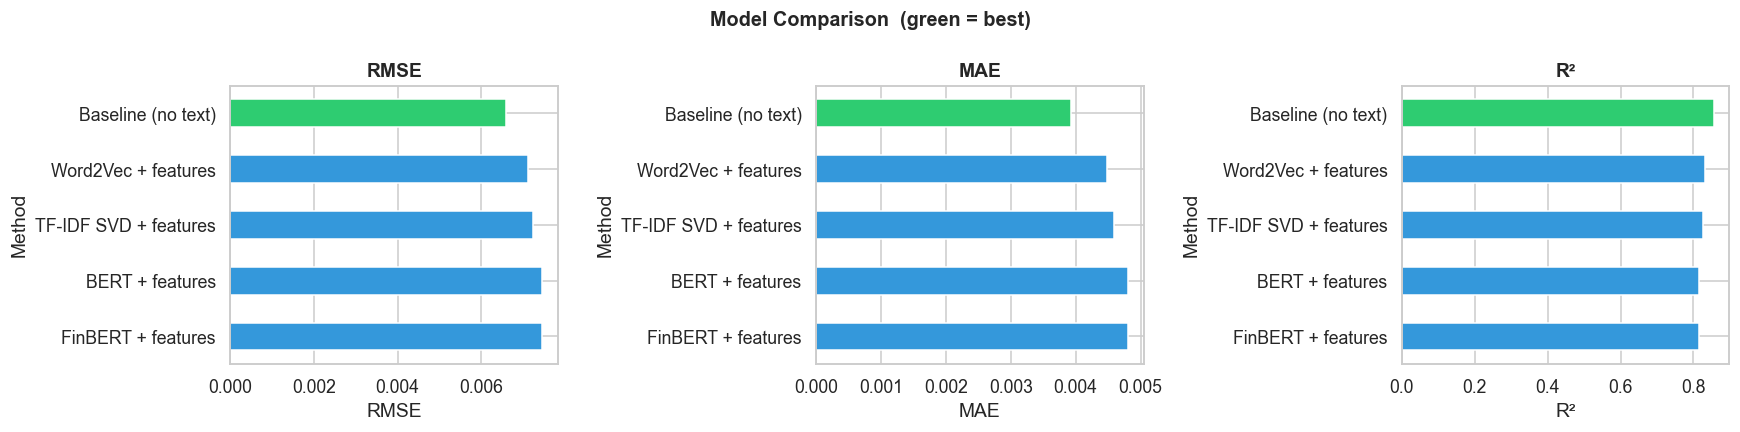


Best method : Baseline (no text)
Baseline R² : 0.855935
  Word2Vec + features             ΔR² vs baseline: -0.024340
  TF-IDF SVD + features           ΔR² vs baseline: -0.029838
  BERT + features                 ΔR² vs baseline: -0.040214
  FinBERT + features              ΔR² vs baseline: -0.040943


In [19]:
metrics = ['RMSE', 'MAE', 'R²']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric in zip(axes, metrics):
    ascending = (metric != 'R²')          # lower is better for RMSE/MAE
    vals = results_df[metric].sort_values(ascending=ascending)
    best_val = vals.min() if ascending else vals.max()
    colors = ['#2ecc71' if v == best_val else '#3498db' for v in vals]
    vals.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle('Model Comparison  (green = best)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_method = results_df['R²'].idxmax()
baseline_r2 = results_df.loc['Baseline (no text)', 'R²']
print(f'\nBest method : {best_method}')
print(f'Baseline R² : {baseline_r2:.6f}')
for m in results_df.index:
    if m != 'Baseline (no text)':
        delta = results_df.loc[m, 'R²'] - baseline_r2
        sign  = '+' if delta >= 0 else ''
        print(f'  {m:<30}  ΔR² vs baseline: {sign}{delta:.6f}')

---
## Feature Importance — Best Model

### Text vs non-text split

In [20]:
best_model, best_feat_names, best_c2c = trained_models[best_method]

importances = best_model.get_feature_importance()
fi_df = (
    pd.DataFrame({'feature': best_feat_names, 'importance': importances})
    .assign(category=lambda x: x['feature'].map(best_c2c).fillna('other'))
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

text_imp = fi_df.loc[fi_df['category'] == 'text_embedding', 'importance'].sum()
meta_imp = fi_df.loc[fi_df['category'] != 'text_embedding', 'importance'].sum()
total    = text_imp + meta_imp

print(f'=== [{best_method}] Text vs Non-text Importance ===')
print(f'  Text embeddings : {text_imp:.2f}  ({100*text_imp/total:.1f}%)')
print(f'  Non-text features: {meta_imp:.2f}  ({100*meta_imp/total:.1f}%)')

=== [Baseline (no text)] Text vs Non-text Importance ===
  Text embeddings : 0.00  (0.0%)
  Non-text features: 100.00  (100.0%)


### Importance by feature category

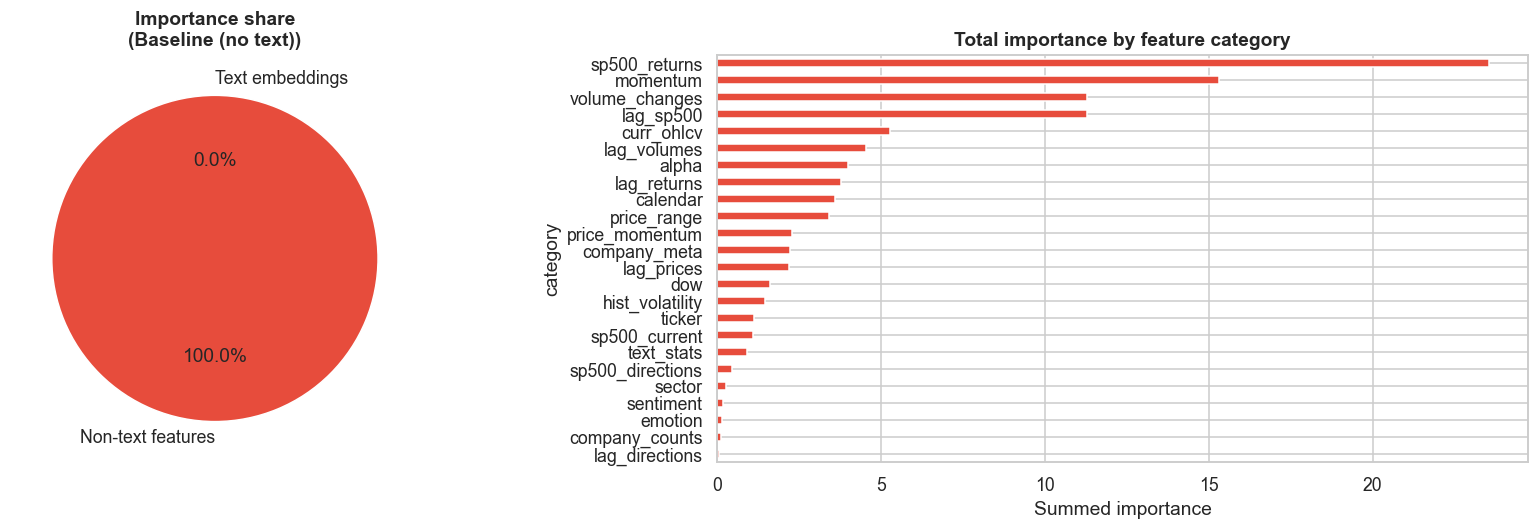


Category importance table (all non-text groups):
category
sp500_returns       23.561
momentum            15.315
volume_changes      11.292
lag_sp500           11.284
curr_ohlcv           5.254
lag_volumes          4.542
alpha                3.992
lag_returns          3.782
calendar             3.580
price_range          3.398
price_momentum       2.283
company_meta         2.211
lag_prices           2.171
dow                  1.594
hist_volatility      1.461
ticker               1.116
sp500_current        1.098
text_stats           0.907
sp500_directions     0.450
sector               0.251
sentiment            0.166
emotion              0.153
company_counts       0.102
lag_directions       0.039


In [21]:
cat_imp = (
    fi_df.groupby('category')['importance']
    .sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── pie: text vs non-text ─────────────────────────────────────────────────────
axes[0].pie(
    [text_imp, meta_imp],
    labels=['Text embeddings', 'Non-text features'],
    autopct='%1.1f%%',
    colors=['#3498db', '#e74c3c'],
    startangle=90,
)
axes[0].set_title(f'Importance share\n({best_method})', fontweight='bold')

# ── bar: per category ─────────────────────────────────────────────────────────
colors_bar = ['#3498db' if c == 'text_embedding' else '#e74c3c'
              for c in cat_imp.index]
cat_imp.sort_values().plot(kind='barh', ax=axes[1], color=colors_bar[::-1],
                           edgecolor='white')
axes[1].set_title('Total importance by feature category', fontweight='bold')
axes[1].set_xlabel('Summed importance')

plt.tight_layout()
plt.show()

print('\nCategory importance table (all non-text groups):')
cat_imp_pct = (cat_imp / total * 100).round(3)
print(cat_imp_pct[cat_imp_pct.index != 'text_embedding'].to_string())

### Top-30 individual non-text features

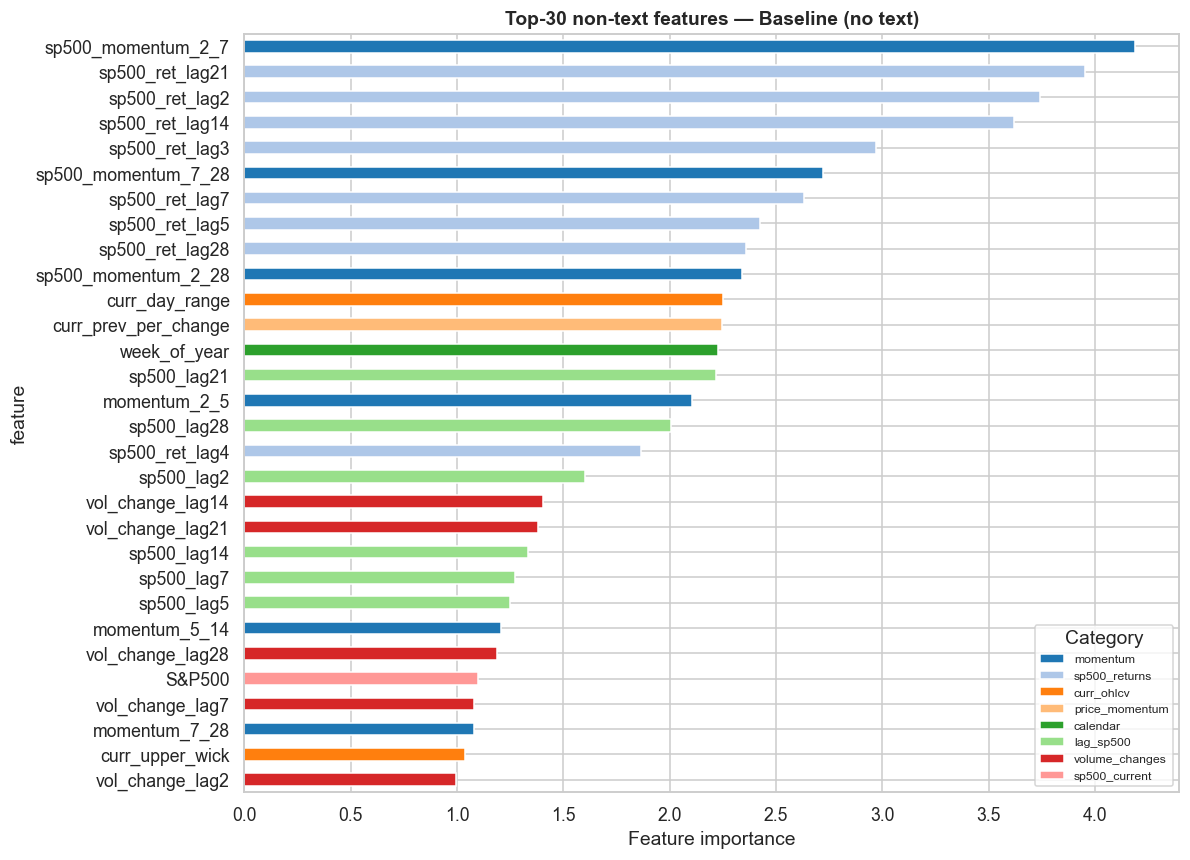

In [22]:
top_non_text = (
    fi_df[fi_df['category'] != 'text_embedding']
    .nlargest(30, 'importance')
    .set_index('feature')
)

# colour bars by category
palette = plt.cm.tab20.colors
unique_cats = list(top_non_text['category'].unique())
cat_color = {c: palette[i % len(palette)] for i, c in enumerate(unique_cats)}
bar_colors = [cat_color[c] for c in top_non_text['category']]

fig, ax = plt.subplots(figsize=(11, 8))
top_non_text['importance'].sort_values().plot(
    kind='barh', ax=ax, color=bar_colors[::-1], edgecolor='white'
)
ax.set_title(f'Top-30 non-text features — {best_method}', fontweight='bold')
ax.set_xlabel('Feature importance')

# legend for categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cat_color[c], label=c) for c in unique_cats]
ax.legend(handles=legend_elements, title='Category',
          loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

### Baseline model — category importance (no text, cleaner signal)

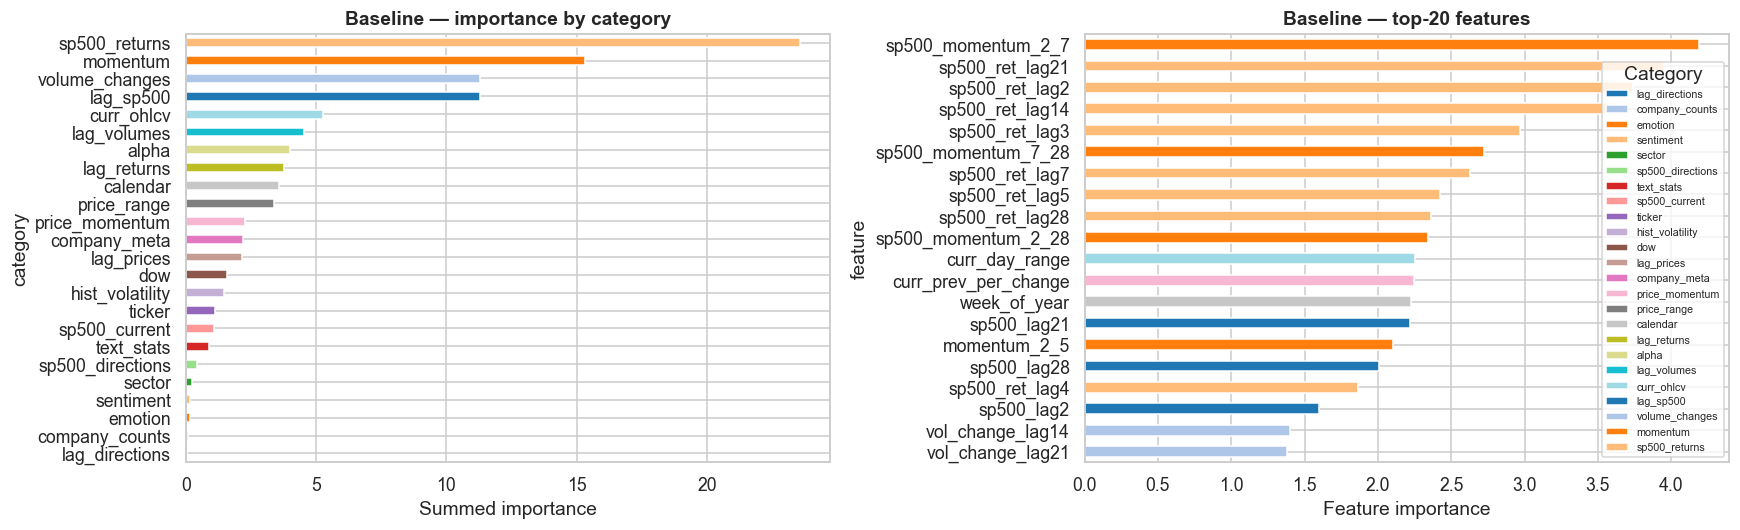


Baseline — category importance % (sorted):
category
sp500_returns       23.56
momentum            15.31
volume_changes      11.29
lag_sp500           11.28
curr_ohlcv           5.25
lag_volumes          4.54
alpha                3.99
lag_returns          3.78
calendar             3.58
price_range          3.40
price_momentum       2.28
company_meta         2.21
lag_prices           2.17
dow                  1.59
hist_volatility      1.46
ticker               1.12
sp500_current        1.10
text_stats           0.91
sp500_directions     0.45
sector               0.25
sentiment            0.17
emotion              0.15
company_counts       0.10
lag_directions       0.04


In [23]:
base_model, base_feat_names, base_c2c = trained_models['Baseline (no text)']
base_imp = base_model.get_feature_importance()

base_fi = (
    pd.DataFrame({'feature': base_feat_names, 'importance': base_imp})
    .assign(category=lambda x: x['feature'].map(base_c2c).fillna('other'))
)

base_cat_imp = (
    base_fi.groupby('category')['importance']
    .sum()
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

palette = plt.cm.tab20.colors
all_cats  = list(base_cat_imp.index)
cat_colors_map = {c: palette[i % len(palette)] for i, c in enumerate(all_cats)}
bar_cols = [cat_colors_map[c] for c in base_cat_imp.index]

base_cat_imp.plot(kind='barh', ax=axes[0], color=bar_cols, edgecolor='white')
axes[0].set_title('Baseline — importance by category', fontweight='bold')
axes[0].set_xlabel('Summed importance')

# Top-20 individual baseline features
top_base = base_fi.nlargest(20, 'importance').set_index('feature')
top_bar_colors = [cat_colors_map.get(c, 'grey') for c in top_base['category']]
top_base['importance'].sort_values().plot(
    kind='barh', ax=axes[1], color=top_bar_colors[::-1], edgecolor='white'
)
axes[1].set_title('Baseline — top-20 features', fontweight='bold')
axes[1].set_xlabel('Feature importance')

legend_elements = [Patch(facecolor=cat_colors_map[c], label=c) for c in all_cats if c in cat_colors_map]
axes[1].legend(handles=legend_elements, title='Category', fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

print('\nBaseline — category importance % (sorted):')
total_base = base_imp.sum()
print((base_cat_imp.sort_values(ascending=False) / total_base * 100).round(2).to_string())